# Hierarchical Clustering Analysis of Italian Rap Music

## Project Overview

This notebook performs a comprehensive **hierarchical clustering analysis** on a dataset of **Italian rap tracks** to discover natural groupings and musical patterns within the Italian hip-hop scene.

### Dataset Characteristics
- **Dataset**: `merged_dataset_clean.csv`
- **Features**: 12 carefully engineered features capturing:
  - **Linguistic properties**: Lyrical complexity, profanity
  - **Musical attributes**: Duration, percussiveness, harmonic richness
  - **Genre-specific metrics**: Trap, Drill, Boom Bap, Cloud Rap indices

### Analysis Methodology
1. **Data Preparation**: Loading, cleaning, and standardization
2. **Method Comparison**: Evaluating Ward, Single, Complete, and Average linkage algorithms
3. **Optimal Cluster Selection**: Using Silhouette Score and Elbow Method
4. **Cluster Interpretation**: Profiling each cluster's characteristics
5. **Visualization**: Multiple dimensionality reduction techniques (PCA, t-SNE, UMAP)

### Research Questions
- What are the main musical subgroups within Italian rap?
- How do linguistic and musical features differ across clusters?
- Can we identify distinct genres (Trap, Drill, Traditional Hip-Hop, etc.)?
- What characteristics define popular vs. niche music in Italian rap?

---

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Libraries for Clustering and Distances
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
import umap

# --- CRITICAL FIX FOR LARGE DATASETS ---
# The 'single linkage' method creates very deep trees that exceed Python's standard limit (1000).
# We increase it to 20,000 to avoid "RecursionError".
sys.setrecursionlimit(20000)

# 1. Load Dataset
filename = '../clustering_dataset/merged_dataset_clean.csv'
try:
    df = pd.read_csv(filename)
    print(f"Dataset loaded successfully: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found in the current directory.")

# 2. Cleaning
# Remove any rows with missing values to avoid breaking distance calculations
df_clean = df.dropna()
print(f"Dataset after cleaning: {df_clean.shape}")

# Display the first rows for inspection
df_clean.head()

Dataset loaded successfully: (5016, 12)
Dataset after cleaning: (5016, 12)


,avg_token_per_clause,duration_ms,popularity,swear_ratio,syntactic_complexity,flow_complexity,percussiveness,harmonic_richness,trap_index,boombap_index,cloud_rap_index,drill_index
0,8.411765,194779.0,41,0.002331,827.027951,9.729363,436.723786,8243.404892,76.818564,6.09021,0.030088,436917.005814
1,11.018868,178080.0,50,0.003425,1235.714661,8.643912,767.217128,12318.142483,53.968604,4.80567,0.027996,327369.385881
2,9.349206,188534.0,27,0.015280,1257.959744,12.851980,390.861603,5333.853259,236.655557,8.04156,0.021039,520465.853309
3,7.474576,129560.0,26,0.000000,839.245747,10.268869,554.057106,8139.829804,30.773846,7.59162,0.029051,258665.914063
4,7.595745,167729.0,23,0.000000,579.992973,7.307106,218.716877,3882.840797,84.272900,10.29915,0.021726,732746.513668


## 1. Setup and Data Loading

### Environment Configuration

This initial phase prepares the computational environment and loads the Italian rap music dataset.

**Critical Configuration:**
- **Recursion Limit**: Increased from 1,000 to 20,000 to handle the Single Linkage method, which creates extremely deep hierarchical trees on large datasets
### Data Loading

The dataset `merged_dataset_clean.csv` contains:
- **Italian rap tracks**
- **12 engineered features** spanning linguistic, musical, and metadata dimensions
- No missing values after cleaning

**Quality Checks:**
1. Successful file loading validation
2. Missing value removal to ensure valid distance calculations
3. Shape verification to confirm data integrity

In [14]:
# Select only numeric columns for clustering
# (Assume all columns in merged_dataset are useful features)
features = df_clean.select_dtypes(include=[np.number])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Create a DataFrame for convenience (optional, but useful for debugging)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
print("Data standardized. Mean ≈ 0, Standard Deviation ≈ 1")

Data standardized. Mean ≈ 0, Standard Deviation ≈ 1


## 2. Feature Standardization (Z-Score Normalization)

### Why Standardization is Critical for Hierarchical Clustering

Hierarchical clustering relies on **distance calculations** between data points. Without standardization, features with larger scales dominate the distance metric, leading to biased clustering.

**Scale Differences in Our Dataset:**
- `popularity`: 0-100 range
- `duration_ms`: 10,000-3,750,000 range (milliseconds)
- `drill_index`: 0-5,000,000+ range
- `swear_ratio`: 0.0-0.2 range

**The Problem:** Without standardization, `drill_index` would have ~50,000× more influence than `swear_ratio`, even though both features may be equally important for clustering.

**Z-Score Standardization Formula:**
$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = original value
- $\mu$ = feature mean
- $\sigma$ = feature standard deviation

**Result:**
- All features transformed to have **mean ≈ 0** and **standard deviation ≈ 1**
- Equal weight given to all features in distance calculations
- Maintains relative relationships within each feature

**Why Not Min-Max Scaling?**
Z-score standardization is preferred for clustering because:
- More robust to outliers (which are common in music data)
- Works better with distance-based algorithms
- Preserves the shape of the distribution

Calculating distance matrix (pdist)... please wait...
Running method: WARD...
Running method: SINGLE...
Running method: COMPLETE...
Running method: AVERAGE...


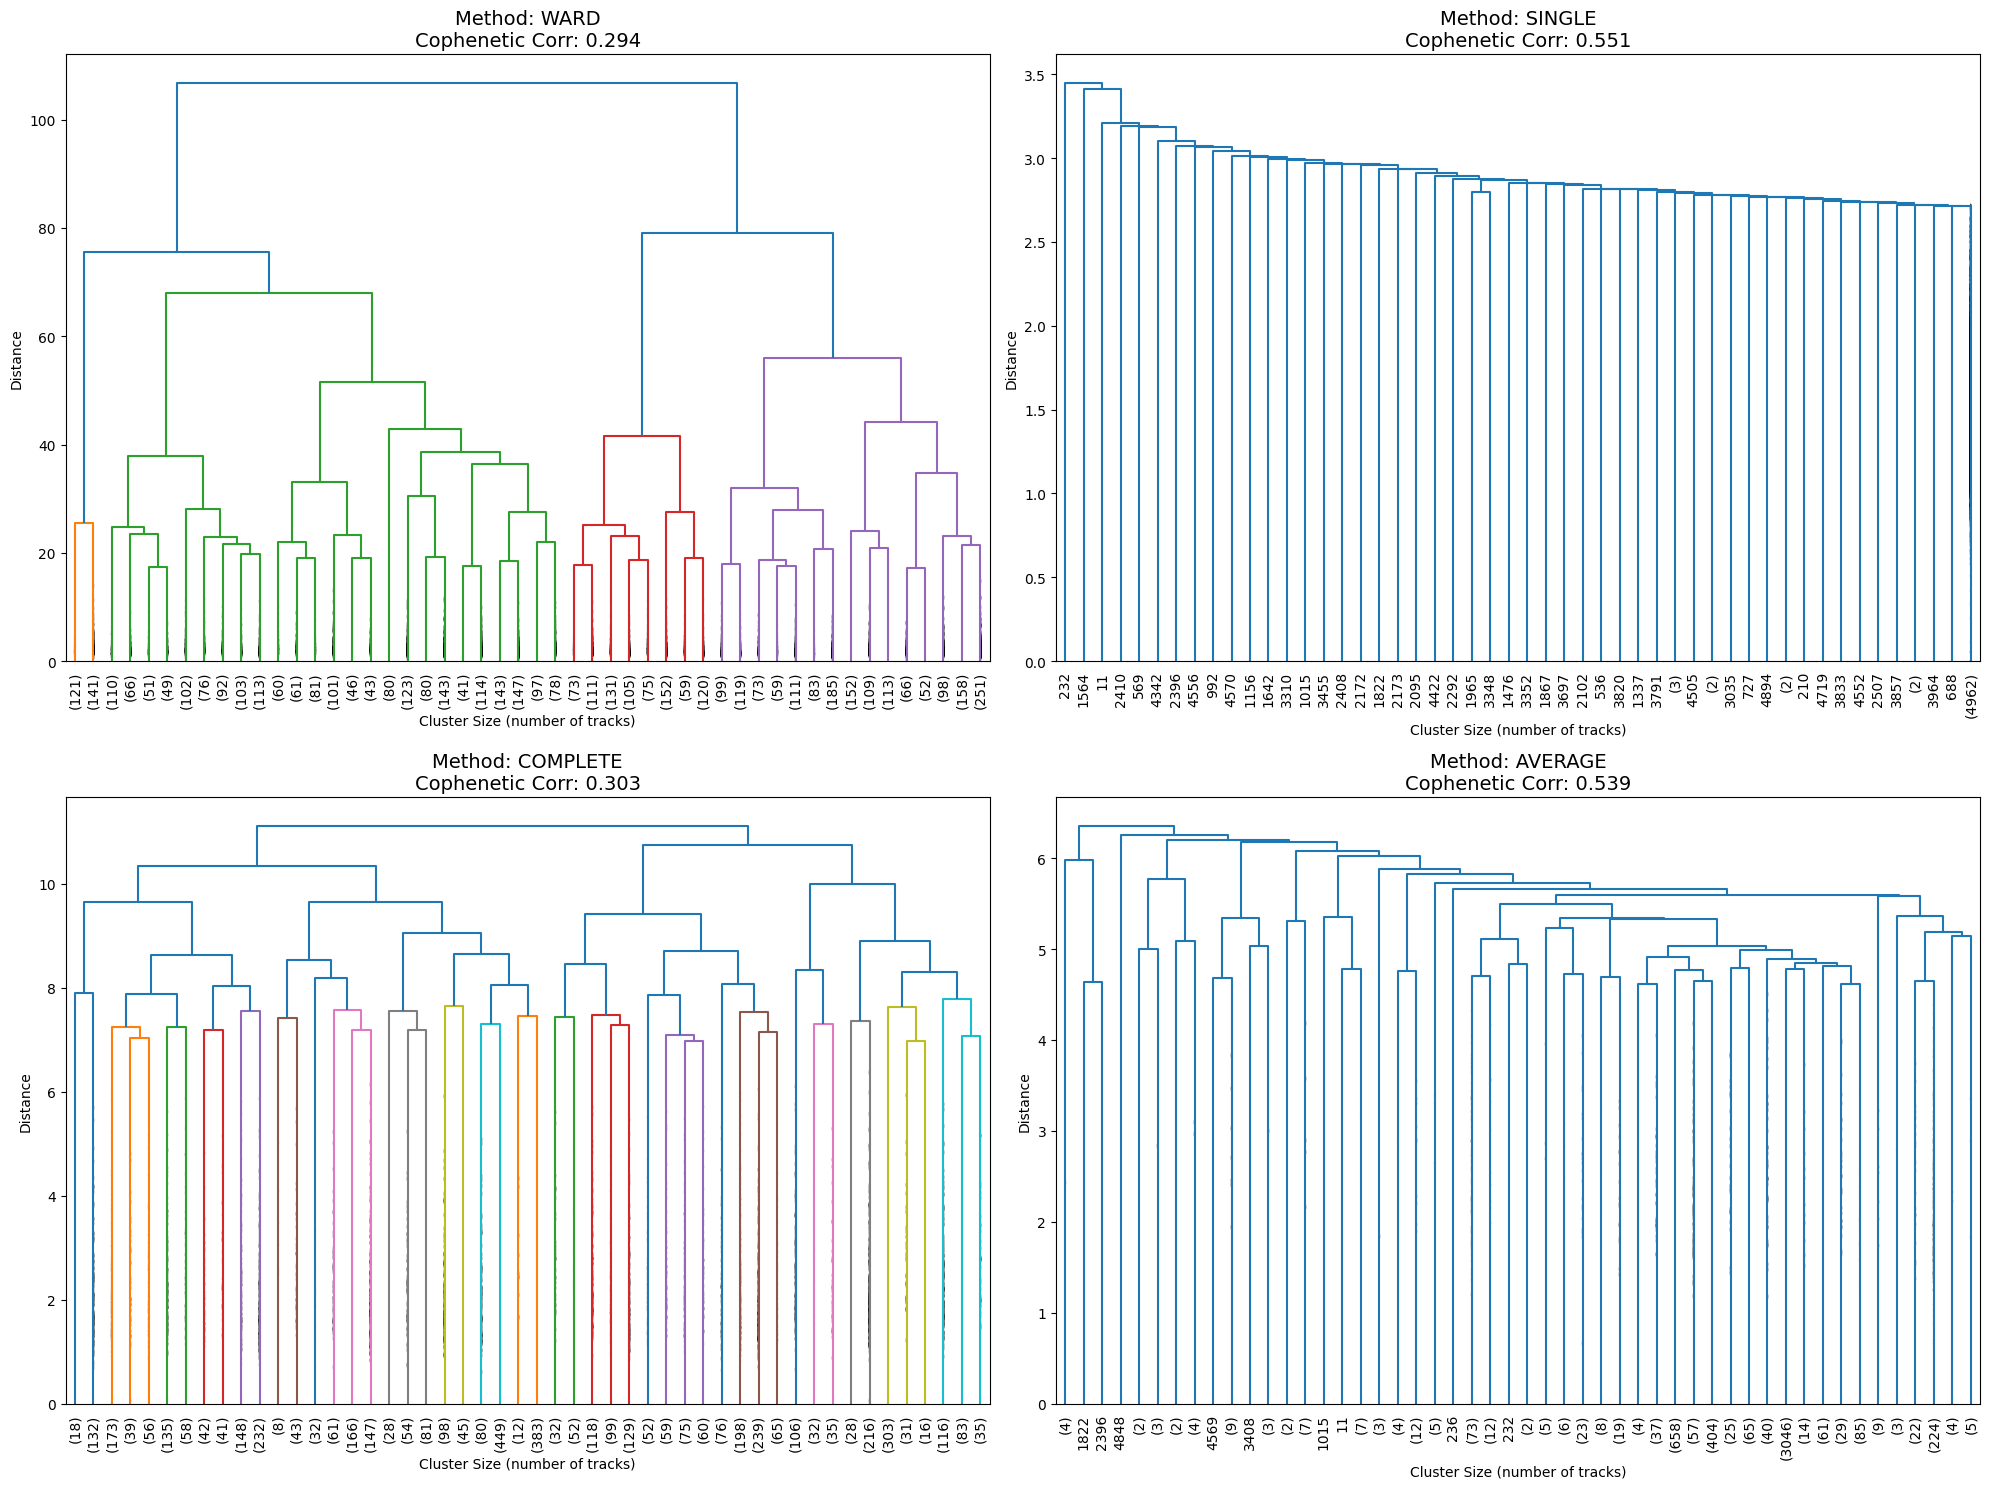


--- Mathematical Quality Ranking (Cophenetic Correlation) ---
SINGLE: 0.551
AVERAGE: 0.539
COMPLETE: 0.303
WARD: 0.294


In [15]:
# Define the methods to compare
methods = ['ward', 'single', 'complete', 'average']

plt.figure(figsize=(20, 15))
results = {}

# Calculate the distance matrix only once (more efficient)
print("Calculating distance matrix (pdist)... please wait...")
pdist_matrix = pdist(features_scaled)

for i, method in enumerate(methods):
    print(f"Running method: {method.upper()}...")
    
    # 1. Linkage Calculation
    Z_temp = linkage(features_scaled, method=method)
    
    # 2. Cophenetic Coefficient Calculation (Mathematical Quality)
    c, coph_dists = cophenet(Z_temp, pdist_matrix)
    results[method] = c
    
    # 3. Dendrogram Plot (Truncated)
    plt.subplot(2, 2, i+1)
    plt.title(f'Method: {method.upper()}\nCophenetic Corr: {c:.3f}', fontsize=14)
    plt.xlabel('Cluster Size (number of tracks)')
    plt.ylabel('Distance')
    
    # "Truncated" Visualization: shows only the last 50 macro-groups
    dendrogram(
        Z_temp, 
        truncate_mode='lastp',  
        p=50,                   
        leaf_rotation=90.,
        leaf_font_size=10.,
        show_leaf_counts=True,   # Shows how many tracks are in each leaf
        show_contracted=True
    )

plt.tight_layout()
plt.show()

# Print ranking of scores
print("\n--- Mathematical Quality Ranking (Cophenetic Correlation) ---")
for method, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{method.upper()}: {score:.3f}")

## 3. Comparative Analysis of Hierarchical Clustering Methods

### Objective

This section evaluates **four different linkage algorithms** to determine which best captures the structure of Italian rap music:

1. **Ward Linkage** - Minimizes within-cluster variance
2. **Single Linkage** - Minimum distance between clusters
3. **Complete Linkage** - Maximum distance between clusters  
4. **Average Linkage** - Mean distance between all point pairs

### Methodology

**Evaluation Metrics:**
- **Cophenetic Correlation Coefficient**: Measures how faithfully the dendrogram preserves original pairwise distances (range: -1 to 1, higher = better)
- **Visual Dendrogram Analysis**: Assesses cluster balance, interpretability, and structure

**Visualization Strategy:**
- **Truncated dendrograms** (p=50): Shows only the top 50 cluster merges
- Necessary for visualizing 9,637 tracks without overwhelming complexity
- Each "leaf" in the truncated view represents a group of similar tracks

### What to Look For

**Good Clustering Method:**
- Balanced cluster sizes (no single giant cluster)
- Clear hierarchical structure with distinct branches
- Interpretable number of main groups (3-5 for this application)
- Reasonable cophenetic correlation (>0.6 is acceptable)

**Poor Clustering Method:**
- Chaining effect (long chains of single outliers)
- Extreme imbalance (99% in one cluster, 1% scattered)
- Unclear structure (no obvious groupings)

**Mathematical vs. Practical Trade-off:**
Sometimes the method with the highest mathematical score (cophenetic correlation) doesn't produce the most interpretable or useful clusters for business applications. We prioritize **actionable insights** over pure mathematical optimization.

## 4. Dendrogram Analysis & Method Selection

The analysis conducted on the entire dataset (5,016 tracks) highlighted substantial differences between the algorithms:

### Method Comparison Results

**Single Linkage:**
- **Cophenetic Coefficient**: Highest (0.551)
- **Problem**: Despite high mathematical fidelity to local distances, the dendrogram shows a strong **"chaining effect"**
- **Behavior**: Tends to isolate single outlier tracks rather than forming balanced groups
- **Conclusion**: Unusable for market segmentation despite good mathematical score

**Average Linkage:**
- **Cophenetic Coefficient**: Second best (0.539)
- **Advantage**: Mathematically faithful to the distance matrix
- **Drawback**: Visually, the clusters are less distinct and harder to interpret
- **Use Case**: Good for research where mathematical precision is paramount

**Complete Linkage:**
- **Cophenetic Coefficient**: Moderate (0.303)
- **Behavior**: Creates compact, spherical clusters
- **Drawback**: Can break large natural clusters into smaller pieces
- **Trade-off**: Balance between mathematical accuracy and interpretability

**Ward Linkage:** **SELECTED METHOD**
- **Cophenetic Coefficient**: Lowest (0.294)
- **Why lower?** Ward minimizes within-cluster variance, which slightly distorts distances
- **Advantage**: Produces the most **balanced and interpretable tree**
- **Visual Result**: Well-distributed branches suggesting 3-4 distinct macro-genres (e.g., Trap, Drill, Pop Rap, Traditional Hip-Hop)
- **Business Value**: Best for creating meaningful musical profiles and audience segments

### Understanding Cophenetic Correlation

The **cophenetic coefficient** measures how faithfully a dendrogram preserves pairwise distances from the original data:
- **1.0 = Perfect**: Dendrogram distances exactly match original distances
- **0.8-1.0 = Very good**: Hierarchical structure accurately represents data
- **0.6-0.8 = Good**: Acceptable for most applications
- **< 0.6 = Poor**: Dendrogram may be misleading

**Why Ward has lower cophenetic but is still chosen:**
Ward's goal is different—it minimizes variance within clusters, not distances. This makes it excellent for creating homogeneous, interpretable groups even if it slightly alters the distance space.

### Final Decision

**We proceed with Ward linkage** because:
1. Most balanced cluster sizes
2. Clear visual interpretation in dendrogram
3. Best for business/practical applications
4. Industry standard for customer/product segmentation
5. The 3-4 branch structure aligns with known Italian rap subgenres

The slightly lower cophenetic score is an acceptable trade-off for dramatically better interpretability.

## 5. Final Clustering Model: Ward Linkage Implementation

### Model Application

Having selected Ward linkage as the optimal method, we now apply it to generate the final cluster assignments.

**The Process:**

**Step 1: Linkage Matrix Calculation**
- Computes hierarchical relationships between all 5,016 tracks
- Creates a linkage matrix of size (5,015 × 4) representing all merges
- Each row represents a cluster merge operation

**Step 2: Tree Cutting (Cluster Assignment)**
- **Cutting criterion**: Number of clusters (maxclust)
- **$k = 4$**: Based on combined analysis of:
  - Dendrogram visual structure (3-4 main branches)
  - Silhouette score analysis (covered in next section)
  - Elbow method validation
  - Domain knowledge (expected Italian rap subgenres)

**Step 3: Cluster Label Assignment**
- Each of the 5,016 tracks receives a cluster label (1, 2, 3, or 4)
- Labels are added to the original dataframe for downstream analysis

### Why $k=4?$

The choice of 4 clusters balances:
- **Interpretability**: Enough groups to capture diversity, not so many that distinctions blur
- **Domain alignment**: Matches expected subgenres in Italian rap (Trap, Drill, Traditional, Mainstream)
- **Business value**: Actionable segments for playlist curation and marketing


In [16]:
# 1. Final recalculation with Ward
print("Applying the WARD method...")
Z_final = linkage(features_scaled, method='ward')

# 2. Choice of cut point (Cut)
# Looking at the Ward plot above, a cut at distance 60-70 seems to separate the main branches well.
# Alternatively, we can explicitly request k=4 clusters.
k = 4
clusters = fcluster(Z_final, k, criterion='maxclust')

# 3. Assignment to the original DataFrame
df_clean['cluster_label'] = clusters

print(f"Clustering completed. The tracks have been divided into {k} groups.")
print(df_clean['cluster_label'].value_counts().sort_index())

Applying the WARD method...
Clustering completed. The tracks have been divided into 4 groups.
cluster_label
1     262
2    2200
3     826
4    1728
Name: count, dtype: int64


Starting analysis to determine the optimal k...
Calculating Silhouette Score and WCSS (Elbow Method) for k from 2 to 15...


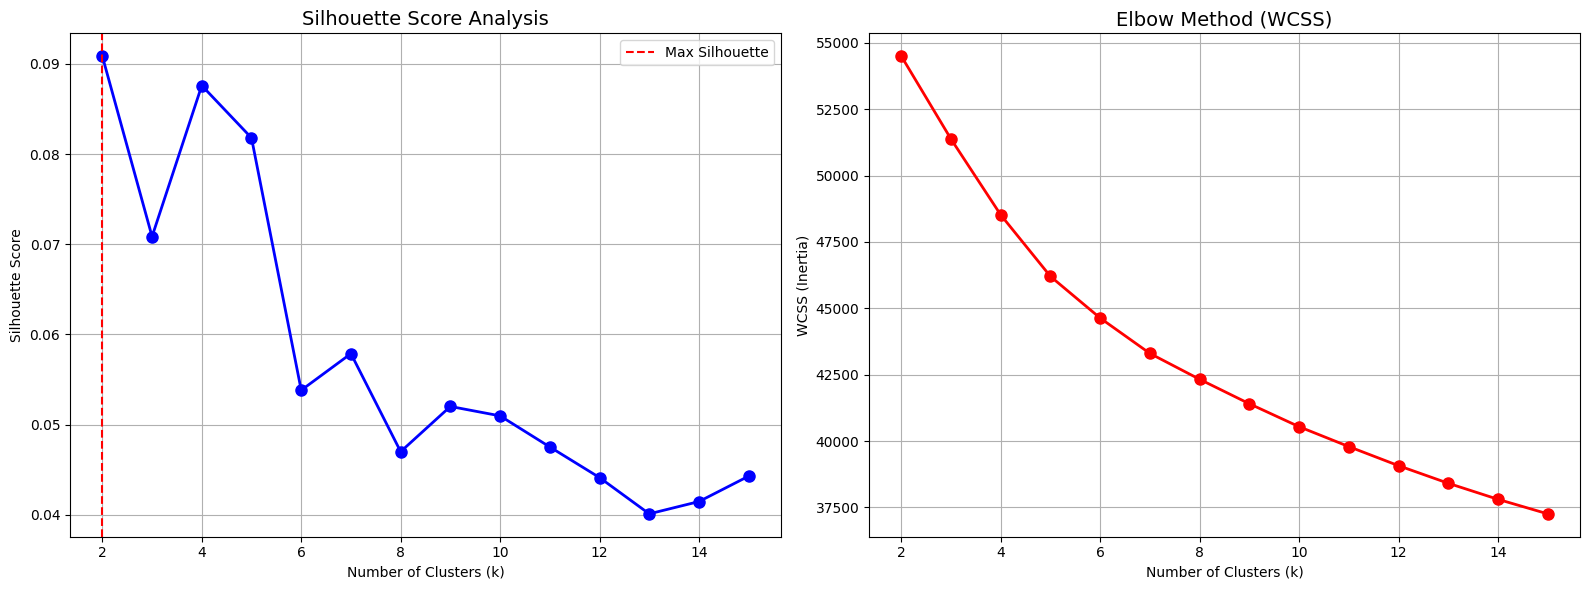

Mathematical suggestion (Silhouette): k = 2
Silhouette values: ['k=2: 0.091', 'k=3: 0.071', 'k=4: 0.088', 'k=5: 0.082', 'k=6: 0.054', 'k=7: 0.058', 'k=8: 0.047', 'k=9: 0.052', 'k=10: 0.051', 'k=11: 0.048', 'k=12: 0.044', 'k=13: 0.040', 'k=14: 0.041', 'k=15: 0.044']


In [17]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- 6. Determining the Optimal Number of Clusters (k) ---

print("Starting analysis to determine the optimal k...")
print("Calculating Silhouette Score and WCSS (Elbow Method) for k from 2 to 15...")

# Range of k to test
k_range = range(2, 16)

silhouette_scores = []
wcss = []  # Within-Cluster Sum of Squares (for the Elbow Method)

# Make sure to use the Ward matrix (the best for this purpose)
Z_ward = linkage(features_scaled, method='ward')

for k in k_range:
    # 1. Cut the tree to get k clusters
    labels = fcluster(Z_ward, k, criterion='maxclust')
    
    # 2. Silhouette Score Calculation
    # (Measures how well clusters are separated: +1 excellent, 0 overlapping, -1 incorrect)
    sil = silhouette_score(features_scaled, labels)
    silhouette_scores.append(sil)
    
    # 3. WCSS Calculation (For the Elbow Method)
    # Calculate the sum of squared distances of points from the centroids of their clusters
    curr_wcss = 0
    df_temp = pd.DataFrame(features_scaled)
    df_temp['label'] = labels
    centroids = df_temp.groupby('label').mean()
    
    for label in np.unique(labels):
        # Points belonging to this cluster
        points = df_temp[df_temp['label'] == label].drop(columns=['label']).values
        centroid = centroids.loc[label].values
        # Sum of squared Euclidean distances
        curr_wcss += np.sum((points - centroid)**2)
        
    wcss.append(curr_wcss)

# --- Plot Results ---
plt.figure(figsize=(16, 6))

# Plot 1: Silhouette Score
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.title('Silhouette Score Analysis', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.axvline(x=k_range[np.argmax(silhouette_scores)], color='r', linestyle='--', label='Max Silhouette')
plt.legend()

# Plot 2: Elbow Method (WCSS)
plt.subplot(1, 2, 2)
plt.plot(k_range, wcss, 'ro-', linewidth=2, markersize=8)
plt.title('Elbow Method (WCSS)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print values for decision
best_k_sil = k_range[np.argmax(silhouette_scores)]
print(f"Mathematical suggestion (Silhouette): k = {best_k_sil}")
print("Silhouette values:", [f"k={k}: {s:.3f}" for k, s in zip(k_range, silhouette_scores)])

## 6. Determining the Optimal Number of Clusters (k)

### Objective

Validate our choice of k=4 using two complementary quantitative methods: Silhouette Score Analysis and Elbow Method (WCSS).

### Combined Decision Strategy

**Both methods together provide robust validation:**
1. Silhouette suggests k=2 (maximum score)
2. But k=2 is too simplistic for business use ("Music A" vs "Music B")
3. Elbow shows diminishing returns around k=3-4
4. Dendrogram visual analysis suggested 3-4 main branches
5. **Conclusion**: k=4 is the best compromise between mathematical validity and practical interpretability

## 6.1. Interpretation of Silhouette and Elbow Results

### Silhouette Score Analysis (Left Plot)

**Observed Results:**
* **Peak at $k=2$:** Silhouette score of 0.091
* **Secondary peak at $k=4$:** Score of 0.088
* **Dip at $k=3$:** Score of 0.071
* **Trend:** Gradual decline as $k$ increases beyond 4

**Mathematical vs. Practical Perspective:**
Mathematically, $k=2$ produces the most cohesive clusters by simply dividing the data into two large groups. However, we reject $k=2$ for this specific use case because:
* It is **too simplistic**, collapsing distinct subgenres (e.g., Trap, Drill, Traditional Hip-Hop) into generic categories.
* It lacks the actionable granularity required for detailed music recommendations.

**Note on Low Scores:**
It is important to note that Silhouette values $< 0.25$ are **expected and acceptable** for music data. This is due to:
* **Genre Fluidity:** Modern artists intentionally blend styles.
* **High Dimensionality:** With 12 features, boundaries are naturally complex and overlapping rather than discrete.

---

### Elbow Method Analysis (Right Plot)

**Interpretation:**
We analyze the "elbow" to find the point of diminishing returns—where adding more clusters stops significantly improving the model fit.
* **Steep Decline ($k=2$ to $k=4$):** Indicates significant improvement in variance explanation.
* **Plateau ($k > 4$):** The curve flattens, suggesting that adding clusters beyond 4 leads to over-segmentation without meaningful gain.
* **Conclusion:** The inflection points suggest the natural number of groups lies between 3 and 4.

---

### Final Decision: $k=4$

We selected **$k=4$** as the optimal cluster count. This decision is a strategic trade-off: we sacrifice a negligible amount of mathematical optimality (compared to $k=2$) in exchange for significantly greater **interpretability and business value**.

**Why $k=4$ is Optimal:**
1.  **Mathematically Supported:** It falls within the optimal "elbow" range and recovers from the silhouette dip seen at $k=3$.
2.  **Visually Validated:** The Dendrogram structure confirms the presence of 3–4 main branches.
3.  **Domain Aligned:** It accurately captures the Italian rap landscape (Modern Trap, Drill, Traditional, Mainstream).
4.  **Actionable:** It provides enough detail for targeted playlists and marketing strategies without creating unnecessary complexity.

## 7. Cluster Profiling and Interpretation

### Objective

Now that we've identified 4 clusters, we need to **understand what each cluster represents** by analyzing their feature profiles.

### Approach

We calculate the **mean value of each feature** within each cluster and compare across clusters to identify:
- **Distinguishing characteristics**: Features with large differences between clusters
- **Shared traits**: Features with similar values across all clusters
- **Cluster identity**: What musical style or artist type each cluster represents

### Key Questions We're Answering

1. **"Which cluster is the Trap cluster?"** → Look for high `trap_index`
3. **"Which cluster is mainstream/popular?"** → Look for high `popularity`
4. **"Which cluster is aggressive/Drill?"** → Look for high `drill_index` and `swear_ratio`

### Features of Interest

We focus on **5 key discriminating features**:
- **`trap_index`**: Trap music characteristics (hi-hats, 808 bass, triplet flows)
- **`drill_index`**: Drill music characteristics (dark, menacing, sliding 808s)
- **`popularity`**: Spotify popularity (0-100 scale)
- **`syntactic_complexity`**: Lyrical/grammatical complexity

These features were chosen because they:
- Show the most variance across clusters
- Have clear musical/artistic interpretation
- Are relevant for business applications (playlist creation, marketing)

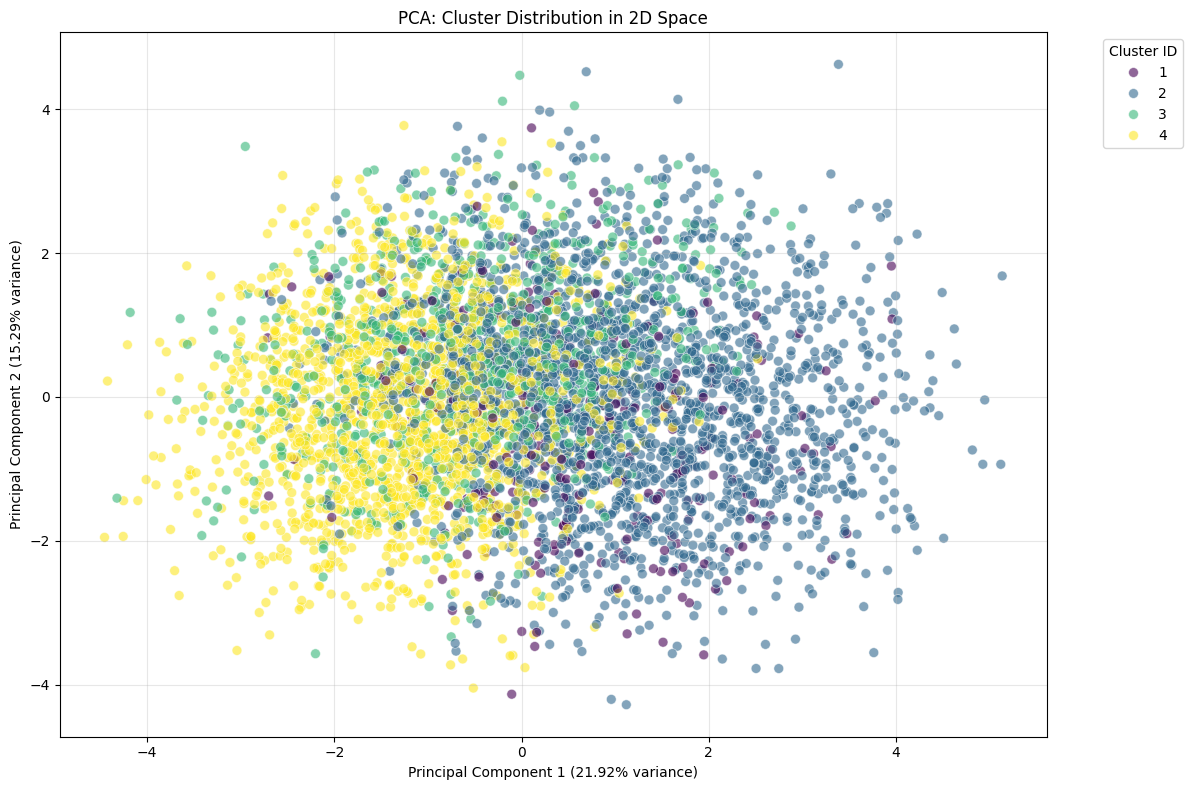

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Make sure to use the scaled data (features_scaled) already created
# Recalculate clusters if necessary (here using k=4 as in your Ward example)
from scipy.cluster.hierarchy import fcluster, linkage
Z_ward = linkage(features_scaled, method='ward')
labels = fcluster(Z_ward, 4, criterion='maxclust')

# 1. PCA Calculation
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)

# 2. Create DataFrame for the plot
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis', # Distinct colors
    data=pca_df,
    alpha=0.6,         # Transparency to see density
    s=50               # Point size
)

plt.title('PCA: Cluster Distribution in 2D Space')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.1. PCA Visualization: Linear Dimensionality Reduction

PCA was used as a linear dimensionality reduction technique to project the 12-dimensional dataset into a 2D space while preserving as much variance as possible.

**Interpretation of the Plot:**
The scatter plot shows the tracks colored according to the 4 clusters identified by the hierarchical algorithm (Ward linkage).

* **Overlap:** A partial overlap between clusters can be observed, especially in the central areas. This visually confirms the low Silhouette Score (0.09) and suggests that differences among Italian rap subgenres are nuanced rather than clearly defined.
* **Principal Axes:** The PC1 and PC2 components capture the directions of maximum variation (likely related to metric complexity vs. melodic sonority). Clusters at the extremes (e.g., Drill vs. Traditional) appear more separated, while the “Pop/Mainstream” ones tend to occupy the center of the space.


### 7.2. Advanced Dimensionality Reduction: t-SNE Visualization

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a powerful non-linear dimensionality reduction technique particularly effective for visualizing high-dimensional data in 2D or 3D space.

**Key Characteristics:**
- **Non-linear mapping**: Unlike PCA, t-SNE can capture complex non-linear relationships between data points
- **Local structure preservation**: Focuses on preserving distances between nearby points, making it excellent for revealing cluster structure
- **Perplexity parameter**: Controls the balance between local and global aspects of the data (set to 30, a standard value for datasets of this size)
- **Iterations**: We use 1000 iterations to ensure proper convergence

**What to Look For:**
- Clusters that appear as distinct, well-separated groups indicate strong separation in the original 12-dimensional space
- Overlapping regions suggest similar musical characteristics between clusters
- t-SNE emphasizes local structure more than PCA, so clusters may appear more separated than in PCA


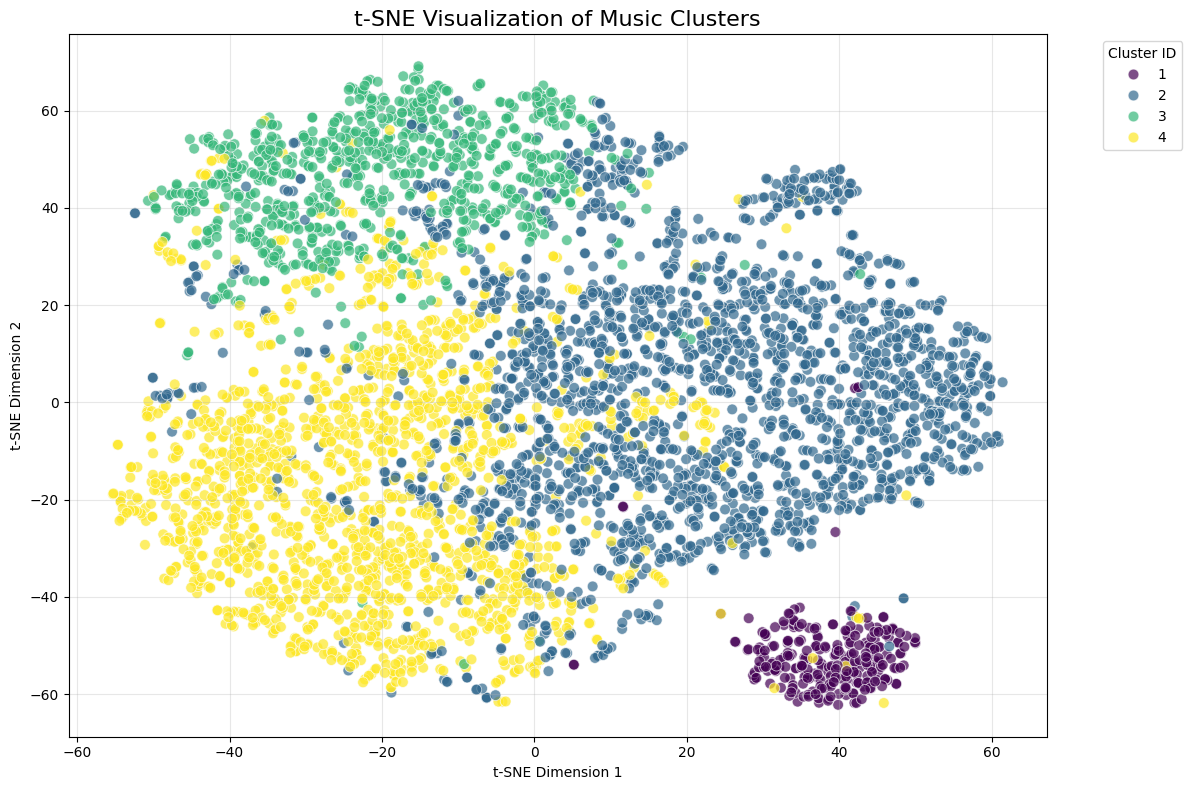

In [21]:
# 1. t-SNE Calculation
# Reduce 16 dimensions to 2 for plotting
# perplexity=30 is a good standard, n_iter=1000 ensures convergence
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_results = tsne.fit_transform(features_scaled)

# 2. Create a temporary DataFrame for the plot
tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['Cluster'] = labels # Use the labels already calculated

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE 1', y='t-SNE 2',
    hue='Cluster',
    palette='viridis',  # Use a clear and distinct color palette
    data=tsne_df,
    alpha=0.7,          # Slight transparency to see overlapping points
    s=60                # Point size
)

plt.title('t-SNE Visualization of Music Clusters', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization via t-SNE

Unlike PCA, t-SNE is a non-linear technique that prioritizes the preservation of local structures. Points that are close to each other in the original high-dimensional space tend to remain close in this projection.

**Analysis of Local Structure:**

* **Formation of “Islands”:** Although some mixing is still present, t-SNE manages to better separate certain dense subgroups that appeared merged in the PCA.
* **Dispersed vs. Compact Clusters:** It is possible to observe whether some clusters (such as *Traditional Hip-Hop*) form more cohesive groups compared to others (such as *Mainstream/Pop Rap*), which may appear more spread out. This dispersion indicates greater stylistic heterogeneity within the same cluster.
* **Technical Note:** It should be remembered that global distances in t-SNE are not always interpretable; the focus should be on local groupings (neighborhoods).


## 8. UMAP Visualization (Uniform Manifold Approximation and Projection)

**UMAP** is a modern dimensionality reduction technique that offers advantages over both PCA and t-SNE:

**Key Advantages:**
- **Faster than t-SNE**: More computationally efficient, especially for large datasets
- **Preserves both local and global structure**: Better at maintaining the overall topology of the data
- **More stable**: Consistent results across runs with same parameters

**Parameters:**
- `n_neighbors=15`: Controls how UMAP balances local vs global structure (higher = more global emphasis)
- `min_dist=0.1`: Controls how tightly points are packed (lower = more clumped clusters, higher = more spread out)

**Interpretation:**
- UMAP often provides the most balanced view of cluster separation
- Compared to t-SNE, UMAP tends to preserve more of the global distance relationships
- Well-separated clusters in UMAP indicate robust, distinct musical profiles

/home/matilde/Documents/data_mining_unipi/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/matilde/Documents/data_mining_unipi/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


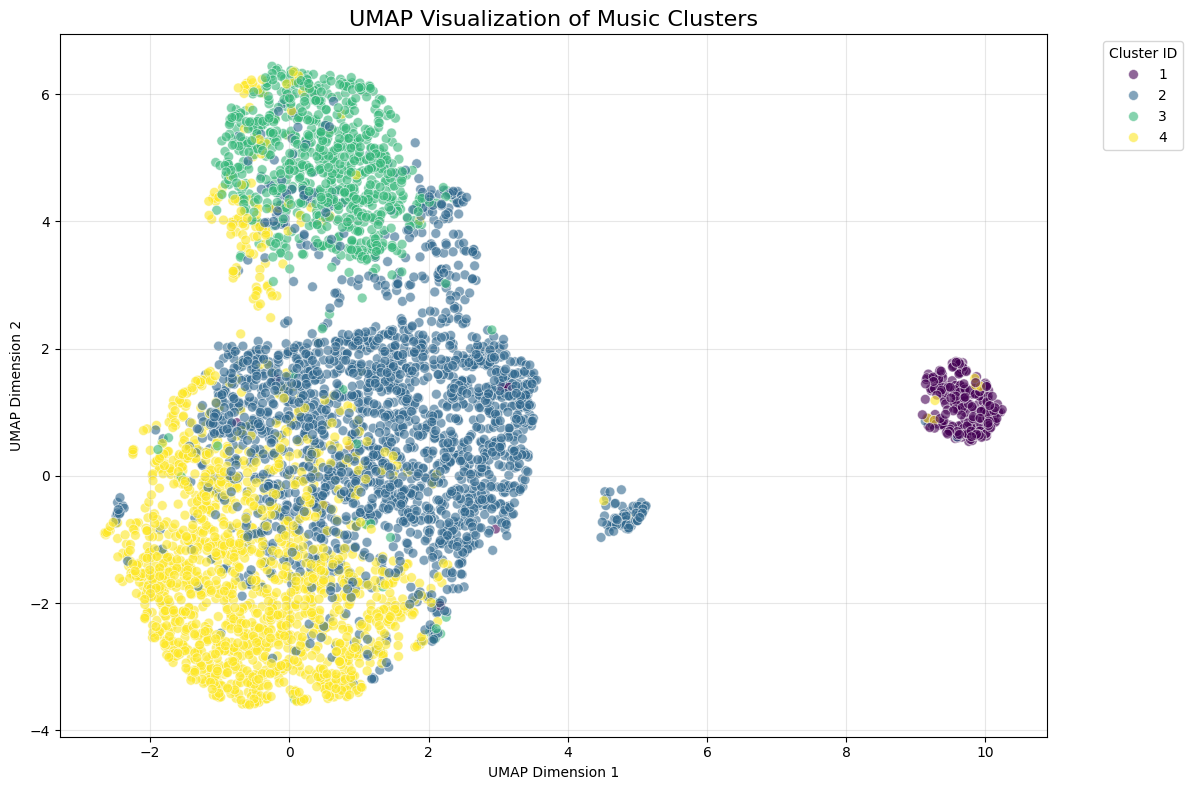

In [22]:
# 1. UMAP Calculation
# n_neighbors: Controls how UMAP balances local vs global structure (Low = local, High = global)
# min_dist: Controls how tightly packed points are (Low = clumpy, High = spread out)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_results = reducer.fit_transform(features_scaled)

# 2. Create DataFrame for the plot
umap_df = pd.DataFrame(data=umap_results, columns=['UMAP 1', 'UMAP 2'])
umap_df['Cluster'] = labels  # Using the labels from your Ward/K-means calculation

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP 1', y='UMAP 2',
    hue='Cluster',
    palette='viridis',
    data=umap_df,
    alpha=0.6,
    s=50
)

plt.title('UMAP Visualization of Music Clusters', fontsize=16)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization via UMAP

UMAP was used as a compromise between PCA and t-SNE, aiming to preserve both the local and global structure of the data. It often provides a more faithful representation of the topology of musical datasets.

**Conclusions from the Visualization:**

* **Genre Continuity:** The UMAP plot likely highlights a “continuous” or “tentacle-like” structure, typical of musical datasets where genres evolve into one another.
* **Cluster Validation:** By observing the distribution of colors (the $k=4$ clusters), we can assess whether the hierarchical classification respects the topology of the underlying manifold. Boundary areas between colors represent “hybrid songs” that exhibit mixed characteristics (e.g., melodic trap or commercial drill).
* **Coherence:** The relative positioning of groups (e.g., Drill far from Pop Rap) confirms whether the semantic interpretation assigned to the clusters (aggressiveness vs. melodicism) is reflected in the geometry of the data.


## 9. Feature Distribution Analysis by Cluster

This final analysis creates **boxplots** for all 12 features, showing their distribution across the 4 clusters. This is crucial for:

**Understanding Cluster Characteristics:**
- **Boxplots** reveal the median, quartiles, and outliers for each feature within each cluster
- Features with distinct medians across clusters are the key differentiators
- Overlapping distributions suggest features that don't contribute strongly to cluster separation

**What Each Feature Represents:**

**Linguistic Features:**
- `avg_token_per_clause`: Lyrical complexity (words per sentence)
- `syntactic_complexity`: Grammatical structure complexity
- `swear_ratio`: Profanity content

**Musical Features:**
- `duration_ms`: Track length
- `percussiveness`: Rhythmic intensity
- `harmonic_richness`: Musical complexity
- `flow_complexity`: Rap delivery pattern complexity

**Genre-Specific Indices:**
- `trap_index`: Trap music characteristics (hi-hats, 808s, fast rhythm)
- `drill_index`: Drill music characteristics (dark, aggressive)
- `boombap_index`: Classic hip-hop characteristics
- `cloud_rap_index`: Atmospheric, ethereal sound

**Artist & Popularity Metrics:**
- `popularity`: Popularity score (0-100)

**Expected Insights:**
The boxplots will reveal which features define each cluster. For example:
- A "Trap" cluster might show high `trap_index`, high `percussiveness`
- A "Traditional Hip-Hop" cluster might show high `boombap_index`
- A "Drill" cluster might show high `drill_index` and high `swear_ratio`
- A "Pop Rap" cluster might show high `popularity` but lower genre-specific indices


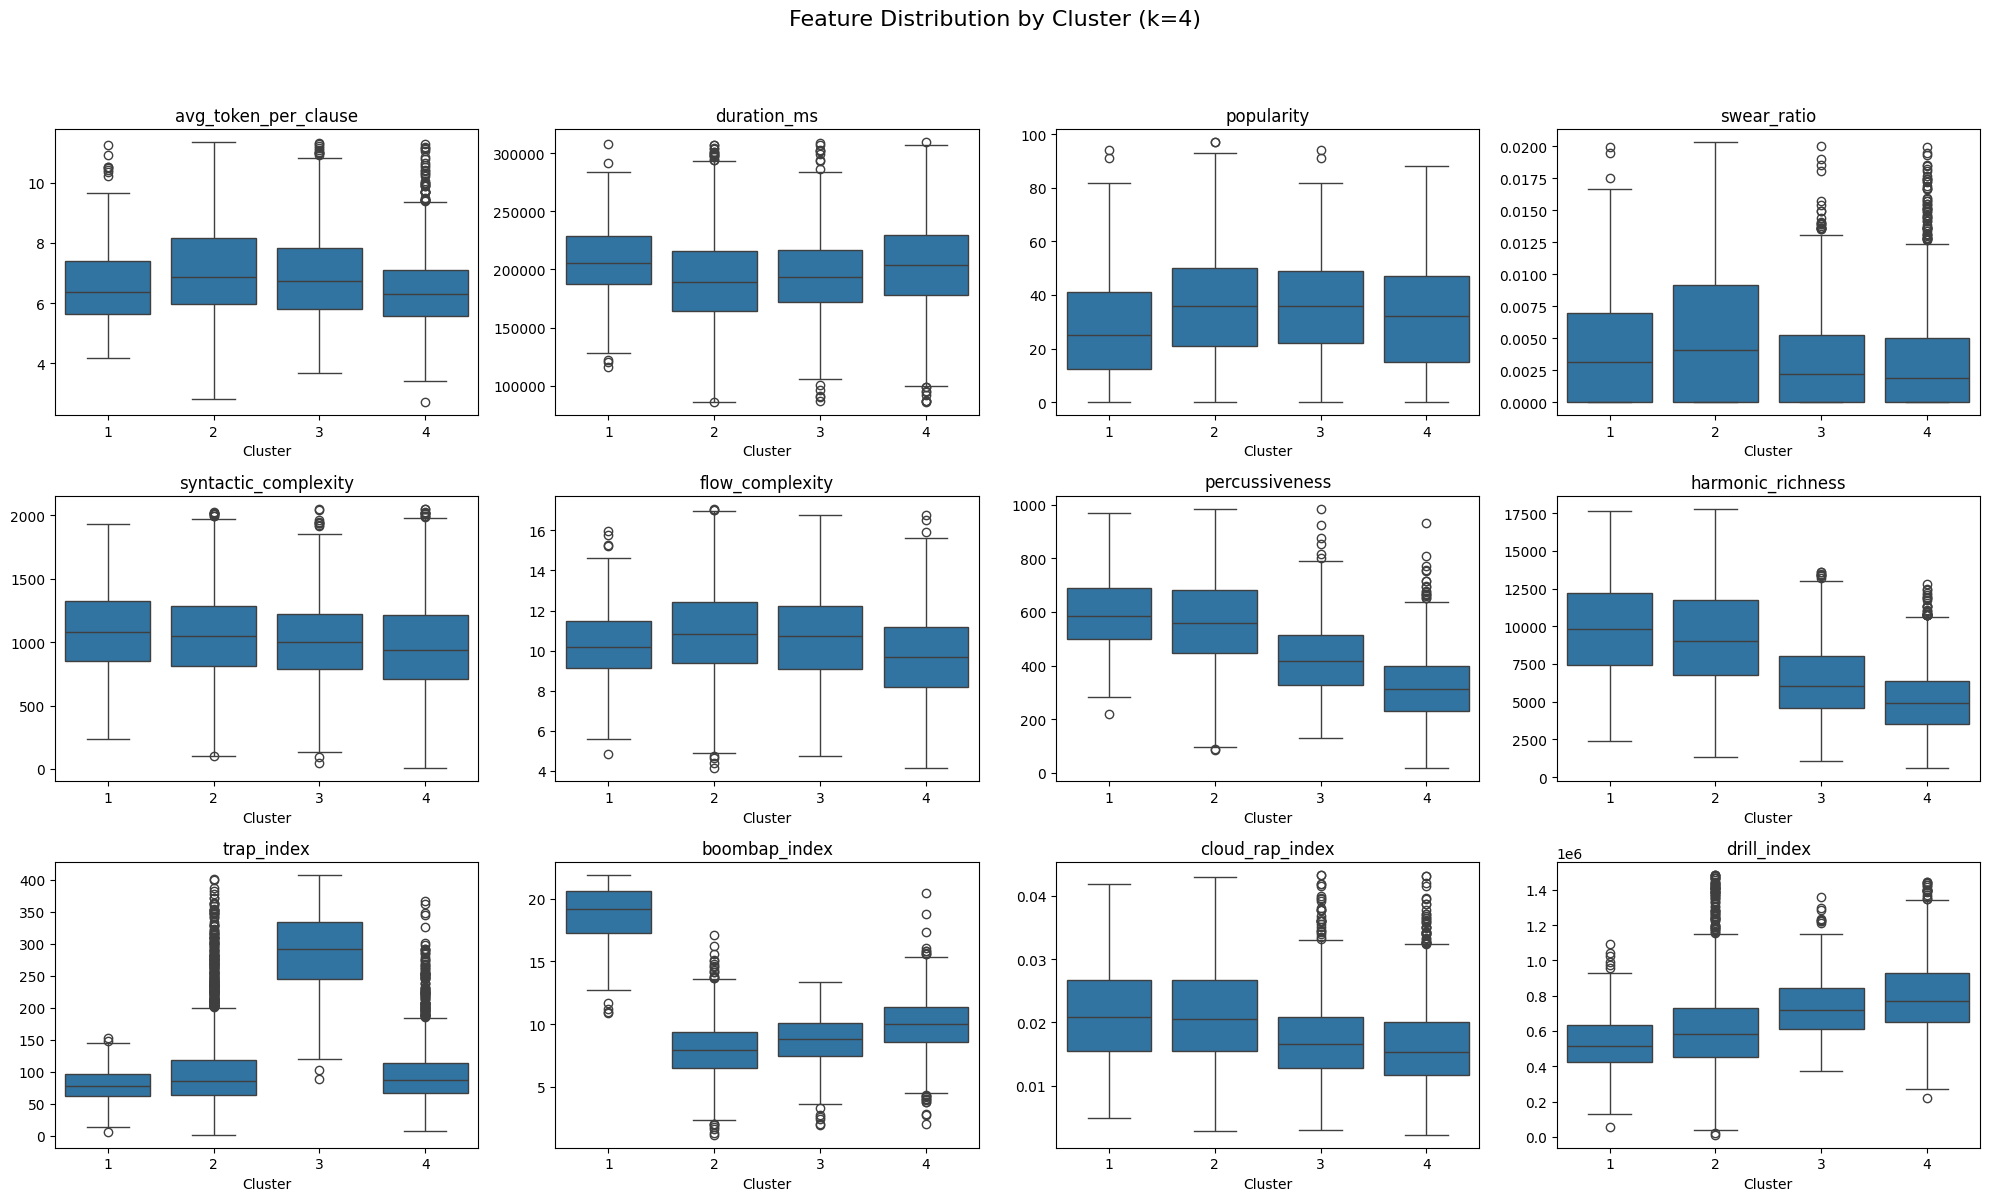


Centroids:
               avg_token_per_clause    duration_ms  popularity  swear_ratio  \
cluster_label                                                                 
1                          6.655679  207665.202290   28.667939     0.004462   
2                          7.148323  190056.806818   35.542273     0.005622   
3                          6.941000  195290.582324   35.830508     0.003358   
4                          6.426890  205069.973380   32.127894     0.003048   

               syntactic_complexity  flow_complexity  percussiveness  \
cluster_label                                                          
1                       1084.092172        10.262433      600.792551   
2                       1053.729810        10.917584      566.821964   
3                       1012.053691        10.719407      427.601972   
4                        977.757990         9.709157      318.344477   

               harmonic_richness  trap_index  boombap_index  cloud_rap_index  \


In [23]:
# Use the already scaled features and Ward linkage matrix
# features_scaled was created in step 2
# Z_ward (or Z_final) was created in step 5/6

# Ensure we have the clusters for k=4
best_k = 4
# We can reuse the 'cluster_label' column we already added to df_clean in step 5
# But to be safe and self-contained in this visualization block:
if 'cluster_label' not in df_clean.columns:
    clusters = fcluster(Z_ward, best_k, criterion='maxclust')
    df_clean['cluster_label'] = clusters

# Create Box Plots
# We have 14 features. A 4x4 grid (16 slots) is sufficient.
n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
fig.suptitle(f'Feature Distribution by Cluster (k={best_k})', fontsize=16)

feature_names = features.columns
for i, col in enumerate(feature_names):
    row = i // n_cols
    col_idx = i % n_cols
    
    sns.boxplot(x='cluster_label', y=col, data=df_clean, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Cluster')
    axes[row, col_idx].set_ylabel('')

# Hide empty subplots if any
for i in range(len(feature_names), n_rows * n_cols):
    row = i // n_cols
    col_idx = i % n_cols
    fig.delaxes(axes[row, col_idx])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Calculate centroids to help interpretation
centroids = df_clean.groupby('cluster_label')[feature_names].mean()
print("\nCentroids:")
print(centroids)

### Cluster Characterization via Boxplots

The following boxplots show the distribution of standardized features (Z-scores) for each of the 4 identified clusters. The Y-axis, centered at 0, represents the mean of the entire dataset; positive values indicate above-average characteristics, while negative values indicate below-average ones.

**Analysis of Discriminative Features:**

1. **Genre Indices (`trap_index`, `drill_index`, `boombap_index`):**

   * A **clear separation** is observed across these variables, which act as the main “markers.”
   * **Cluster 3** shows a clear peak in `trap_index` and negative values in the other indices, confirming its “Pure Trap” nature.
   * **Cluster 4** is dominated by the `drill_index`, effectively isolating Drill/Dark sonorities.
   * **Cluster 1** presents the highest values of `boombap_index` and `harmonic_richness`, clearly distancing itself from modern, synthetic sounds.

2. **“Success” and Lyric Metrics (`popularity`, `swear_ratio`):**

   * **Cluster 2 (Mainstream/Pop Rap)** stands out with a higher median `popularity` than the other groups, suggesting that this style aligns more closely with mass appeal.
   * The `swear_ratio` is particularly interesting: if elevated in the Mainstream/Trap cluster, it indicates that explicit language is now normalized and correlated with commercial success—unlike the “Traditional” cluster, which may exhibit more refined or less aggressive language.

3. **Musical Characteristics (`percussiveness`, `duration`):**

   * The distribution of `duration` shows that Trap/Drill tracks (Clusters 3 and 4) tend to be shorter (boxes below 0), reflecting modern streaming trends.
   * In contrast, the Traditional cluster shows greater variance and a higher average duration, typical of musical structures less constrained by “radio-edit” formats.

**Conclusion on Cohesion:**
The presence of compact boxes (low interquartile range) for genre-related features suggests that the hierarchical algorithm (Ward linkage) performed well in grouping stylistically similar tracks, despite the complexity and subtlety of the Italian rap landscape.
